In [7]:
# Imports 
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [8]:
# load testing data set and drop null values
df = pd.read_csv("../data/raw/testing_dataset.csv")
df = df.dropna(subset=["text"])

In [9]:
df.head()

,label,text
0,Ham,houshyar kim would like take dinner hows sched...
1,Spam,subject strike iron hot hello name wayne like ...
2,Ham,the language of the stipulation is if the mou ...
3,Spam,dsfsdfsdfs
4,Ham,"vince ,\n?\njust to let you know , the books w..."


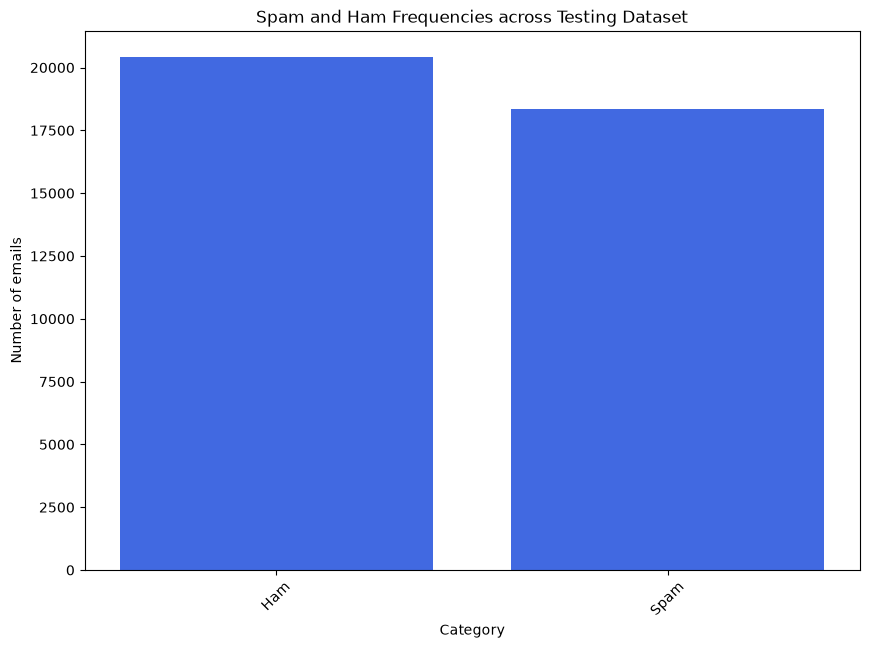

Test set spam: 18339 (47.3%)
Test set ham: 20432 (52.7%)


In [10]:
category_counts = df['label'].value_counts()
plt.figure(figsize=(10,7))
plt.bar(category_counts.index, category_counts.values, color='royalblue')
plt.title('Spam and Ham Frequencies across Testing Dataset')
plt.xticks(rotation=45) # Rotate labels to avoid overlap
plt.ylabel("Number of emails")
plt.xlabel("Category")
plt.show()

train_counts = df["label"].value_counts()
train_total = len(df)

test_counts = df["label"].value_counts()
test_total = len(df)
print(f"Test set spam: {test_counts['Spam']} ({test_counts['Spam']/test_total:.1%})")
print(f"Test set ham: {test_counts['Ham']} ({test_counts['Ham']/test_total:.1%})")


In [11]:
# clean and tokanize
pattern = re.compile(r'[^a-zA-Z\s]+')
noise_pattern = re.compile(r'escapenumber|escapelong', re.IGNORECASE)
stopwords = {'y', 'did', 'i', 'again', "hadn't", 'my', 'over', 'too', 'here', "that'll", 'couldn', 'than', "they've", 'same', "she's", 'they', 'doing', 'if', 'down', "don't", 'out', 'no', 'her', 're', 'such', 't', "i've", 'only', 'was', 'shouldn', "they'd", 'won', 'more', 'needn', 'do', "shouldn't", "wasn't", "aren't", 'aren', 'how', 'shan', 'doesn', 'few', 'll', 'myself', "couldn't", "he'd", 'other', 'wasn', 'his', 'on', 'these', 'both', "didn't", 'you', "you've", 'their', 'what', "you'd", 'being', 'by', 'been', 's', 'ain', 'why', 'where', 'until', 'as', 'off', 'after', 'is', 'be', 'below', 'hasn', 'yours', 'we', 'has', 'own', 've', 'haven', 'whom', 'wouldn', 'hers', "we'd", 'between', 'o', "he's", 'have', 'herself', 'does', 'now', "shan't", 'don', 'in', 'so', 'from', 'a', 'under', 'further', 'those', 'me', 'most', "weren't", 'against', 'its', 'she', 'at', "you'll", 'yourself', "i'll", 'm', 'once', 'mustn', 'while', 'should', 'ours', 'didn', 'then', 'when', 'that', 'were', "it'd", 'which', 'above', 'all', "doesn't", "mustn't", "she'd", "it's", 'before', 'of', 'and', 'weren', "she'll", 'our', 'will', 'isn', "i'm", 'had', 'to', 'the', 'through', 'with', 'there', 'during', 'or', "haven't", 'himself', 'it', 'theirs', "wouldn't", 'each', 'not', 'just', 'this', "we'll", "he'll", "needn't", "we've", 'ourselves', 'about', "isn't", 'your', 'nor', 'because', 'can', 'he', 'am', "i'd", "should've", 'any', 'd', 'some', 'having', 'ma', 'itself', 'into', "we're", "hasn't", "they'll", 'who', 'are', 'but', 'themselves', "mightn't", "it'll", 'very', 'for', 'hadn', "you're", 'him', 'them', 'an', "they're", 'mightn', "won't", 'yourselves', 'up'}
NOISE_WORDS = {"subject", "pm", "org", "com", "http", "www"}

def clean(email: str, strip_placeholders: bool = True, remove_stopwords: bool = True, remove_noise_words: bool = True) -> list[str]:
    if strip_placeholders:
        email = noise_pattern.sub('', email)
    
    words = email.lower().split()
    words = [pattern.sub('', w) for w in words]
    
    words = [
        w for w in words
        if w and len(w) > 1
        and (not remove_stopwords or w not in stopwords)
        and (not remove_noise_words or w not in NOISE_WORDS)
    ]
    return words

In [12]:
def clean_params(version: int = 1) -> tuple[bool, bool, bool]:
    placeholders, stopw, noisew = True, True, True

    match version:
        case 1:
            pass
        case 2:
            noisew = False
        case 3:
            stopw = False
        case 4:
            stopw, noisew = False, False
        case 5:
            placeholders = False
        case 6:
            placeholders, noisew = False, False
        case 7:
            placeholders, stopw = False, False
        case 8:
            placeholders, stopw, noisew = False, False, False
        case _:
            raise ValueError(f"Unknown version: {version}")

    return placeholders, stopw, noisew

In [13]:
# Prediction
def load_model(path="../models/modelv4.json"):
    with open(path, "r") as f:
        model = json.load(f)
    vocab = model["vocab"]
    log_prior_s, log_prior_h = np.array(model["log_priors"])
    log_likelihoods = np.array(model["log_likelihoods"])
    return vocab, log_prior_s, log_prior_h, log_likelihoods

def predict(email, vocab, log_prior_s, log_prior_h, log_likelihoods, clean_fn):
    cleaned = clean_fn(email)
    
    log_post_spam = log_prior_s
    log_post_ham = log_prior_h
    
    for word in cleaned:
        index = vocab.get(word)
        if index is None:
            continue
        log_post_spam += log_likelihoods[0][index]
        log_post_ham += log_likelihoods[1][index]

    return "spam" if log_post_spam > log_post_ham else "ham"

In [14]:
# compute the true positives, true negatives, false positives and false negavitves 
# negative is ham and positive is spam 
# tp are emails classified as spam and are spam 
# tn are emails classified as ham and are ham 
# fp are emails classified as spam but are ham 
# fn are emails classified as ham but are spam 

def confusion(model_path: str, test_df, clean): 
    vocab, log_prior_s, log_prior_h, log_likelihoods = load_model(model_path)
    tp, tn, fp, fn = 0, 0, 0, 0

    for index, row in test_df.iterrows():
        label = row["label"].lower()
        email = row["text"]

        prediction = predict(email, vocab, log_prior_s, log_prior_h, log_likelihoods, clean)

        match (label, prediction):
            case ("spam", "spam"):
                tp += 1
            case ("ham", "ham"):
                tn += 1
            case ("ham", "spam"):
                fp += 1
            case ("spam", "ham"):
                fn += 1
                
    confusion_matrix = np.vstack([[tp, fn], [fp, tn]])
    
    return confusion_matrix, tp, tn, fp, fn, len(vocab)

In [ ]:
model_performance = []
version = 0
model_config = {
    f"../models/modelv{version}.json": (lambda email, v = version : clean(email, *clean_params(v)))
    for version in range(1, 9)
}

for i, (model, clean_fn) in enumerate(model_config.items()):
    confusion_matrix, tp, tn, fp, fn, vocab_size = confusion(model, df, clean_fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    model_performance.append({
        "Model": f"version {i + 1}", 
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Accuracy": accuracy,
        "Vocab size": vocab_size
    })
    print(f"Evaluated {model}")

In [18]:
results_df = pd.DataFrame(model_performance)
results_df.head(8)

,Model,Precision,Recall,F1-score,Accuracy,Vocab size
0,version 1,0.975073,0.944926,0.959763,0.962524,364103
1,version 2,0.975055,0.946344,0.960485,0.963168,364109
2,version 3,0.970836,0.947543,0.959049,0.961724,364248
3,version 4,0.969937,0.948252,0.958972,0.961621,364254
4,version 5,0.980657,0.934402,0.956971,0.960254,376162
5,version 6,0.979959,0.935874,0.957409,0.960615,376168
6,version 7,0.976403,0.936365,0.955965,0.959196,376307
7,version 8,0.975827,0.937728,0.956398,0.959557,376313


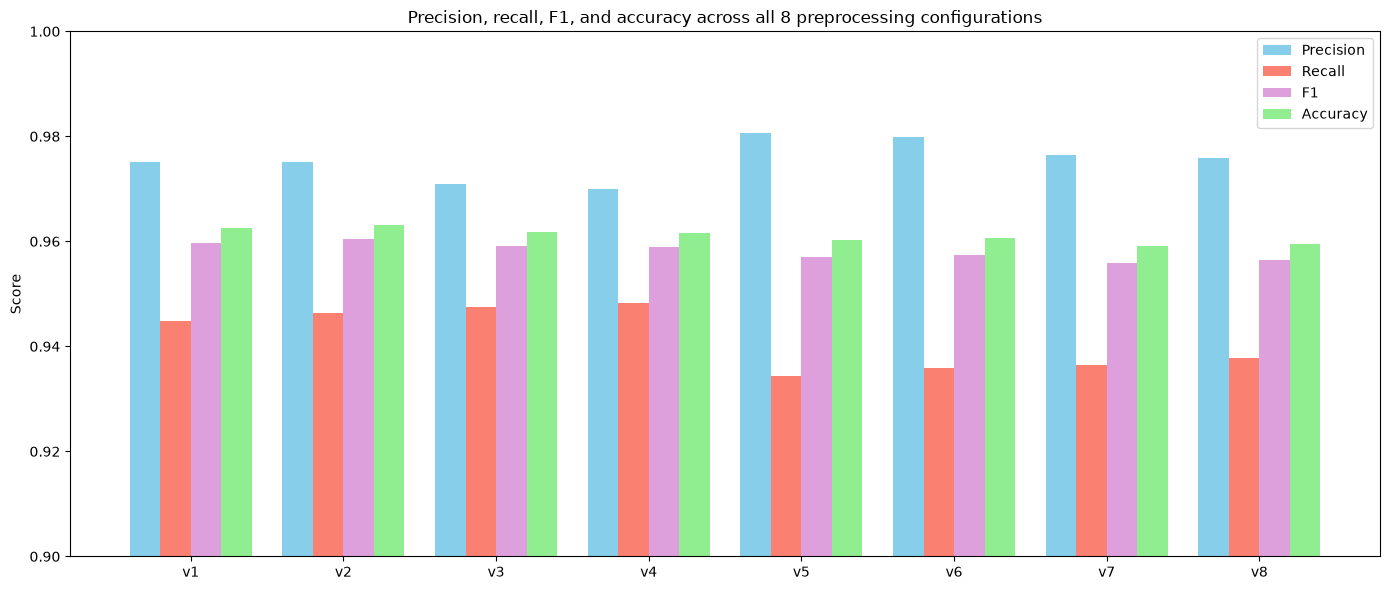

In [17]:
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))  # widened to comfortably fit 8 groups of 4 bars
ax.bar(x - 1.5*width, results_df["Precision"], width, label="Precision", color="skyblue")
ax.bar(x - 0.5*width, results_df["Recall"], width, label="Recall", color="salmon")
ax.bar(x + 0.5*width, results_df["F1-score"], width, label="F1", color="plum")
ax.bar(x + 1.5*width, results_df["Accuracy"], width, label="Accuracy", color="lightgreen")

ax.set_xticks(x)
ax.set_xticklabels([f"v{i+1}" for i in range(len(results_df))])
ax.set_ylim(0.9, 1.0)
ax.set_ylabel("Score")
ax.set_title("Precision, recall, F1, and accuracy across all 8 preprocessing configurations")
ax.legend()

plt.tight_layout()
plt.show()